In [25]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 8.21 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/home/jovyan/Mecab-ko-for-Google-Colab/Mecab-ko-for-Google-Colab
install_mecab-ko_on_colab_light_220429.sh: line 4: cd: /content: No such file or directory
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-06-12 05:51:15--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 13.200.41.135, 13.200.41.136, 13.200.41.134, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.135|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-06-1

In [26]:
!python --version

Python 3.12.11


In [27]:
!pip install gensim==4.3.2

In [28]:
# 의존성 연결을 위해 다운그레이드를 진행합니다.
!pip install scipy==1.12.0 numpy==1.26.3

In [29]:
import pandas
import konlpy
import gensim

print(pandas.__version__)
print(konlpy.__version__)
print(gensim.__version__)

2.3.0
0.6.0
4.3.2


In [30]:
import pandas as pd
import os

# 데이터를 읽어봅시다.
train_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_train.txt')
test_data = pd.read_table(os.getenv("HOME") + '/work/sentiment_classification/data/ratings_test.txt')

train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [31]:
from konlpy.tag import Mecab
import numpy as np
from collections import Counter

tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(10000-4)
    vocab = ['', '', '', ''] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index[''] for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

In [32]:
index_to_word = {index:word for word, index in word_to_index.items()}

In [33]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수
# 단, 모든 문장은 <BOS>로 시작

def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in sentence.split()]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

문장 평균 길이: 15.97
문장 최대 길이: 116
문장 표준편차: 12.84


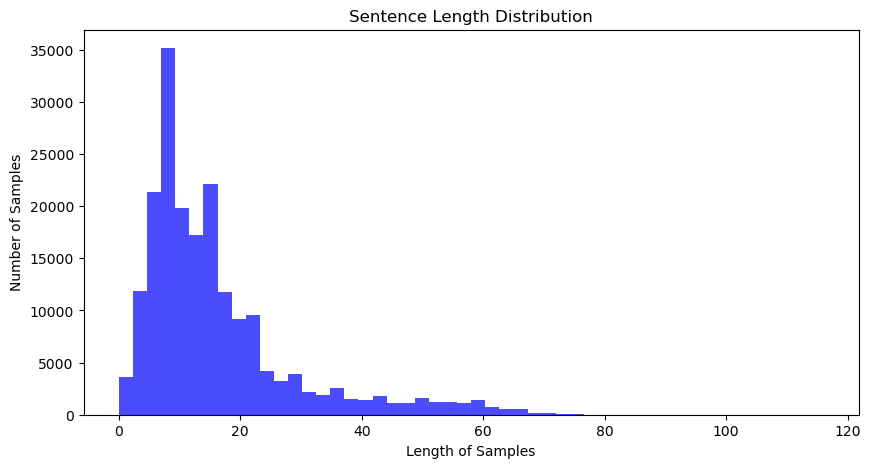


설정한 최대 길이(max_len): 41
전체 문장 중 41 이하인 문장의 비율: 93.43%


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 1) 전체 데이터의 길이 분포 확인
num_tokens = [len(tokens) for tokens in X_train] + [len(tokens) for tokens in X_test]
num_tokens = np.array(num_tokens)

# 평균, 최댓값, 표준편차 계산
mean_len = np.mean(num_tokens)
max_len_data = np.max(num_tokens)
std_len = np.std(num_tokens)

print(f"문장 평균 길이: {mean_len:.2f}")
print(f"문장 최대 길이: {max_len_data}")
print(f"문장 표준편차: {std_len:.2f}")

# 2) 적절한 최대 문장 길이(max_len) 지정
# 통상적으로 '평균 + 2*표준편차' 공식을 사용하거나 데이터의 95% 이상을 덮는 길이를 선택합니다.
max_len = int(mean_len + 2 * std_len)
pad_ratio = np.sum(num_tokens <= max_len) / len(num_tokens)

print(f"max_len: {max_len}")
print(f" {max_len} 이하인 문장비율: {pad_ratio * 100:.2f}%")

In [35]:
import torch
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F

# 0번 인덱스를 <PAD> 토큰으로 가정
PAD_TOKEN = 0

# 먼저 max_len보다 긴 문장들을 잘라줍니다 (Truncating)
X_train_trunc = [torch.tensor(seq[:max_len]) for seq in X_train]
X_test_trunc = [torch.tensor(seq[:max_len]) for seq in X_test]


# Pre Padding 

def pad_sequences_pre(tensor_list, max_length, pad_value=0):
    padded_list = []
    for tensor in tensor_list:
        pad_len = max_length - tensor.size(0)
        # F.pad(입력 텐서, (왼쪽 패딩, 오른쪽 패딩), value)
        if pad_len > 0:
            padded_tensor = F.pad(tensor, (pad_len, 0), value=pad_value)
        else:
            padded_tensor = tensor
        padded_list.append(padded_tensor)
    return torch.stack(padded_list)

X_train_padded_pre = pad_sequences_pre(X_train_trunc, max_length=max_len, pad_value=PAD_TOKEN)
X_test_padded_pre = pad_sequences_pre(X_test_trunc, max_length=max_len, pad_value=PAD_TOKEN)


# 라벨 데이터 -->텐서 변환
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


print("X_train (Pre-padded) shape:", X_train_padded_pre.shape)
print("y_train shape:", y_train_tensor.shape)


X_train (Pre-padded) shape: torch.Size([146182, 41])
y_train shape: torch.Size([146182])


In [36]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# 하이퍼파라미터 설정
BATCH_SIZE = 64
VOCAB_SIZE = 10000  # 앞서 설정한 단어 사전의 크기
EMBEDDING_DIM = 128 # 임베딩 벡터의 차원

# 1) Train / Validation 데이터 비율(8:2)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_padded_pre, y_train_tensor, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train_tensor # 긍정/부정 클래스 비율 유지
)

print(f"훈련 데이터 갯수: {len(X_train_split)}")
print(f"검증 데이터 갯수: {len(X_val_split)}")

# 2) TensorDataset 및 DataLoader 생성
train_dataset = TensorDataset(X_train_split.long(), y_train_split)
val_dataset = TensorDataset(X_val_split.long(), y_val_split)
test_dataset = TensorDataset(X_test_padded_pre.long(), y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

훈련 데이터 갯수: 116945
검증 데이터 갯수: 29237


In [ ]:
## 1. 3개 모델 학습: 1-D CNN, LSTM, Global Average Pooling

In [74]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# 1) 1-D CNN
class CNN1DModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters=256, kernel_size=3):
        super(CNN1DModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1d = nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=kernel_size)
        self.fc = nn.Linear(num_filters, 1)

    def forward(self, x):
        x = x.long() # 입력 데이터는 정수형으로 변환
        embedded = self.embedding(x).permute(0, 2, 1)
        conved = F.relu(self.conv1d(embedded))
        pooled = F.max_pool1d(conved, kernel_size=conved.shape[2]).squeeze(-1)
        return self.fc(pooled).squeeze(-1)

# 2) RNN (LSTM)
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim=128, num_layers=1):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.long() # 입력 데이터는 정수형으로 변환
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        return self.fc(hidden[-1]).squeeze(-1)

# 3) Global Average Pooling
class GlobalAveragePoolingModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(GlobalAveragePoolingModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = x.long() # 입력 데이터는 정수형으로 변환
        embedded = self.embedding(x)
        pooled = embedded.mean(dim=1)
        return self.fc(pooled).squeeze(-1)



[Training 1-D CNN Model]
Epoch 01 | Train Loss: 0.5295 Acc: 73.68% | Val Loss: 0.4536 Acc: 78.77%
Epoch 02 | Train Loss: 0.4144 Acc: 81.24% | Val Loss: 0.4037 Acc: 81.70%
Epoch 03 | Train Loss: 0.3652 Acc: 84.08% | Val Loss: 0.3810 Acc: 82.93%
Epoch 04 | Train Loss: 0.3305 Acc: 86.04% | Val Loss: 0.3698 Acc: 83.49%
Epoch 05 | Train Loss: 0.3027 Acc: 87.66% | Val Loss: 0.3607 Acc: 83.90%
Epoch 06 | Train Loss: 0.2785 Acc: 88.93% | Val Loss: 0.3564 Acc: 84.18%
Epoch 07 | Train Loss: 0.2570 Acc: 90.09% | Val Loss: 0.3537 Acc: 84.38%
Epoch 08 | Train Loss: 0.2370 Acc: 91.16% | Val Loss: 0.3555 Acc: 84.39%
Epoch 09 | Train Loss: 0.2187 Acc: 92.05% | Val Loss: 0.3547 Acc: 84.48%
Epoch 10 | Train Loss: 0.2016 Acc: 92.96% | Val Loss: 0.3606 Acc: 84.32%


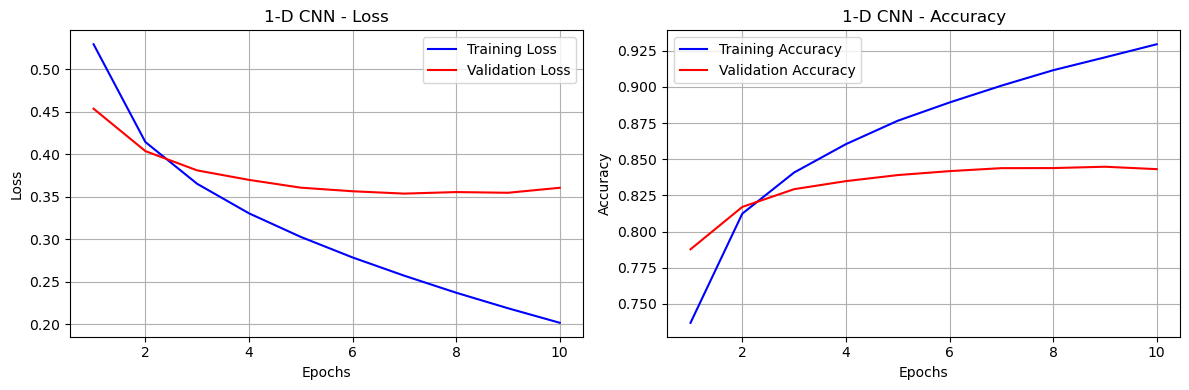


[Training LSTM Model]
Epoch 01 | Train Loss: 0.5421 Acc: 72.16% | Val Loss: 0.4597 Acc: 78.20%
Epoch 02 | Train Loss: 0.4272 Acc: 80.28% | Val Loss: 0.4058 Acc: 81.25%
Epoch 03 | Train Loss: 0.3827 Acc: 82.85% | Val Loss: 0.3803 Acc: 82.81%
Epoch 04 | Train Loss: 0.3561 Acc: 84.26% | Val Loss: 0.3666 Acc: 83.86%
Epoch 05 | Train Loss: 0.3361 Acc: 85.46% | Val Loss: 0.3616 Acc: 84.27%
Epoch 06 | Train Loss: 0.3195 Acc: 86.27% | Val Loss: 0.3505 Acc: 84.55%
Epoch 07 | Train Loss: 0.3044 Acc: 87.10% | Val Loss: 0.3473 Acc: 84.50%
Epoch 08 | Train Loss: 0.2915 Acc: 87.78% | Val Loss: 0.3444 Acc: 84.88%
Epoch 09 | Train Loss: 0.2808 Acc: 88.29% | Val Loss: 0.3433 Acc: 85.11%
Epoch 10 | Train Loss: 0.2674 Acc: 89.00% | Val Loss: 0.3449 Acc: 85.11%


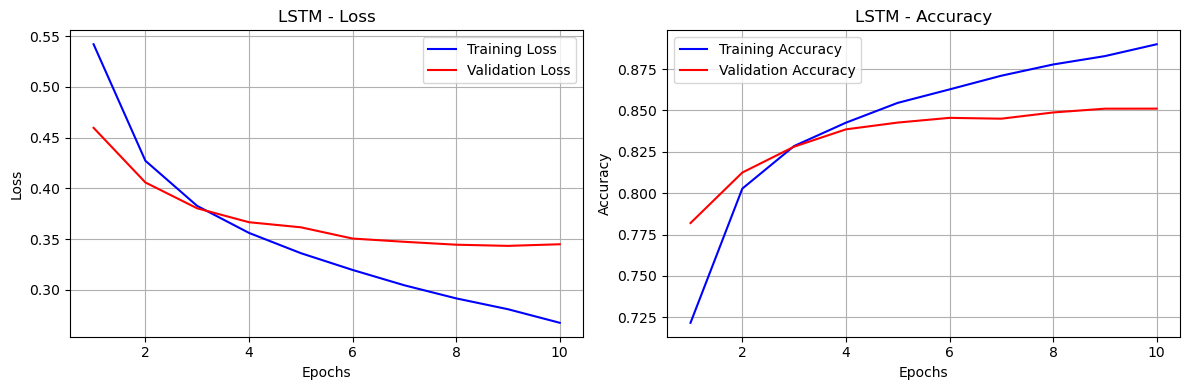


[Training Global Average Pooling Model]
Epoch 01 | Train Loss: 0.6789 Acc: 62.09% | Val Loss: 0.6572 Acc: 69.77%
Epoch 02 | Train Loss: 0.6271 Acc: 72.73% | Val Loss: 0.5920 Acc: 74.92%
Epoch 03 | Train Loss: 0.5618 Acc: 76.27% | Val Loss: 0.5309 Acc: 77.43%
Epoch 04 | Train Loss: 0.5100 Acc: 78.30% | Val Loss: 0.4882 Acc: 79.06%
Epoch 05 | Train Loss: 0.4744 Acc: 79.64% | Val Loss: 0.4597 Acc: 80.16%
Epoch 06 | Train Loss: 0.4495 Acc: 80.69% | Val Loss: 0.4398 Acc: 80.92%
Epoch 07 | Train Loss: 0.4312 Acc: 81.48% | Val Loss: 0.4254 Acc: 81.58%
Epoch 08 | Train Loss: 0.4172 Acc: 82.13% | Val Loss: 0.4145 Acc: 81.94%
Epoch 09 | Train Loss: 0.4059 Acc: 82.73% | Val Loss: 0.4061 Acc: 82.39%
Epoch 10 | Train Loss: 0.3969 Acc: 83.17% | Val Loss: 0.3994 Acc: 82.65%


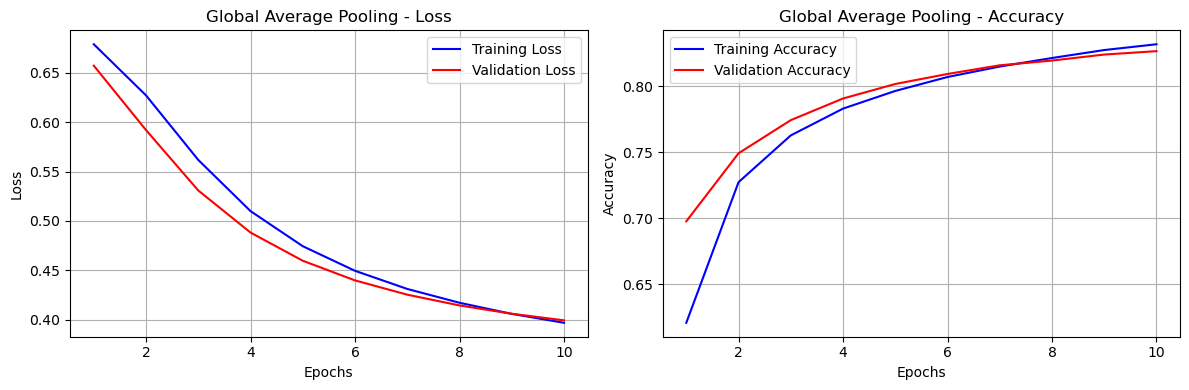

In [76]:
import matplotlib.pyplot as plt
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# 학습 함수 
def train_model(model, train_loader, val_loader, epochs=10, lr=0.0001):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss() # Logits 출력을 위한 손실 함수
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def binary_accuracy(preds, y):
        rounded_preds = torch.round(torch.sigmoid(preds)) # 시그모이드 후 반올림 (0 or 1)
        correct = (rounded_preds == y).float() 
        acc = correct.sum() / len(correct)
        return acc

    for epoch in range(epochs):
        model.train()
        epoch_loss, epoch_acc = 0, 0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            predictions = model(batch_x)
            
            loss = criterion(predictions, batch_y)
            acc = binary_accuracy(predictions, batch_y)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()

        # Validation 평가
        model.eval()
        val_loss, val_acc = 0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                predictions = model(batch_x)
                loss = criterion(predictions, batch_y)
                acc = binary_accuracy(predictions, batch_y)
                
                val_loss += loss.item()
                val_acc += acc.item()

        # 평균 계산 및 기록
        train_l = epoch_loss / len(train_loader)
        train_a = epoch_acc / len(train_loader)
        val_l = val_loss / len(val_loader)
        val_a = val_acc / len(val_loader)

        history['train_loss'].append(train_l)
        history['train_acc'].append(train_a)
        history['val_loss'].append(val_l)
        history['val_acc'].append(val_a)

        print(f"Epoch {epoch+1:02} | Train Loss: {train_l:.4f} Acc: {train_a*100:.2f}% | Val Loss: {val_l:.4f} Acc: {val_a*100:.2f}%")
        
    return history

# 시각화 함수 
def plot_history(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 4))
    
    # Loss 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Accuracy 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


# 실제 실행 부분

# 모델 1 실행
print("\n[Training 1-D CNN Model]")
cnn_model = CNN1DModel(VOCAB_SIZE, EMBEDDING_DIM)
cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=10)
plot_history(cnn_history, "1-D CNN")

# 모델 2 실행
print("\n[Training LSTM Model]")
lstm_model = LSTMModel(VOCAB_SIZE, EMBEDDING_DIM)
lstm_history = train_model(lstm_model, train_loader, val_loader, epochs=10)
plot_history(lstm_history, "LSTM")

# 모델 3 실행
print("\n[Training Global Average Pooling Model]")
gap_model = GlobalAveragePoolingModel(VOCAB_SIZE, EMBEDDING_DIM)
gap_history = train_model(gap_model, train_loader, val_loader, epochs=10)
plot_history(gap_history, "Global Average Pooling")

In [ ]:
## 2. lSTM모델 (word2vec 임베딩 적용)

In [67]:
import os

# 파일 시스템 전체를 뒤져서 모델 파일의 실제 위치를 찾습니다.
found_path = None
for root, dirs, files in os.walk('/'):
    if 'word2vec_ko.model' in files:
        found_path = os.path.join(root, 'word2vec_ko.model')
        print(f"파일을 찾았습니다: {found_path}")
        break

if not found_path:
    print("파일을 찾을 수 없습니다. 왼쪽 파일 아이콘을 눌러 파일을 다시 업로드해주세요.")

파일을 찾았습니다: /home/jovyan/data/word2vec_ko.model


In [68]:
# 검색된 경로로 직접 지정
word2vec_file_path = '/home/jovyan/data/word2vec_ko.model' 
word_vectors = Word2VecKeyedVectors.load(word2vec_file_path)

In [69]:
word2vec_file_path = '/home/jovyan/data/word2vec_ko.model'

In [70]:
# 한국어 Word2Vec 임베딩 활용한 성능개선 #

from gensim.models.keyedvectors import Word2VecKeyedVectors

# 1. 한국어 Word2Vec 로드 및 임베딩 행렬 생성
word2vec_file_path = '/home/jovyan/data/word2vec_ko.model'
word_vectors = Word2VecKeyedVectors.load(word2vec_file_path)
embedding_dim = word_vectors.vector_size # Word2Vec의 차원 자동 추출

# 우리 단어 사전(word_to_index)과 Word2Vec 매핑
embedding_matrix = np.zeros((VOCAB_SIZE, embedding_dim))
for word, idx in word_to_index.items():
    if word in word_vectors.wv:
        embedding_matrix[idx] = word_vectors.wv[word]
    else:
        # 단어장에 없는 단어는 무작위 초기화
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

pretrained_weight = torch.tensor(embedding_matrix, dtype=torch.float32)

# 2. Pre-trained LSTM 모델 정의
class PretrainedLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, pretrained_weight, hidden_dim=128):
        super(PretrainedLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight.data.copy_(pretrained_weight) # 가중치 이식
        self.embedding.weight.requires_grad = True          # Fine-tuning 활성화
        
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.long()
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        return self.fc(hidden[-1]).squeeze(-1)

# 3. 모델 가동
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PretrainedLSTMModel(VOCAB_SIZE, embedding_dim, pretrained_weight).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.BCEWithLogitsLoss()
#

In [71]:
import matplotlib.pyplot as plt

# 기록용 딕셔너리
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

def binary_accuracy(preds, y):
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

for epoch in range(10):
    # --- 학습 단계 ---
    model.train()
    total_loss, total_acc = 0, 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += binary_accuracy(predictions, batch_y).item()
    
    avg_train_loss = total_loss / len(train_loader)
    avg_train_acc = total_acc / len(train_loader)
    
    # --- 검증 단계 ---
    model.eval()
    val_loss, val_acc = 0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item()
            val_acc += binary_accuracy(predictions, batch_y).item()
            
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)
    
    # 기록
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc*100:.2f}% | Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc*100:.2f}%")

Epoch 1 | Train Loss: 0.5068 Acc: 75.12% | Val Loss: 0.4328 Acc: 80.03%
Epoch 2 | Train Loss: 0.4155 Acc: 81.10% | Val Loss: 0.4041 Acc: 81.55%
Epoch 3 | Train Loss: 0.3776 Acc: 83.17% | Val Loss: 0.3668 Acc: 83.50%
Epoch 4 | Train Loss: 0.3522 Acc: 84.38% | Val Loss: 0.3673 Acc: 83.61%
Epoch 5 | Train Loss: 0.3330 Acc: 85.46% | Val Loss: 0.3412 Acc: 84.87%
Epoch 6 | Train Loss: 0.3174 Acc: 86.26% | Val Loss: 0.3377 Acc: 85.07%
Epoch 7 | Train Loss: 0.3031 Acc: 86.87% | Val Loss: 0.3339 Acc: 85.39%
Epoch 8 | Train Loss: 0.2917 Acc: 87.55% | Val Loss: 0.3275 Acc: 85.76%
Epoch 9 | Train Loss: 0.2798 Acc: 88.12% | Val Loss: 0.3267 Acc: 86.10%
Epoch 10 | Train Loss: 0.2705 Acc: 88.63% | Val Loss: 0.3236 Acc: 86.19%


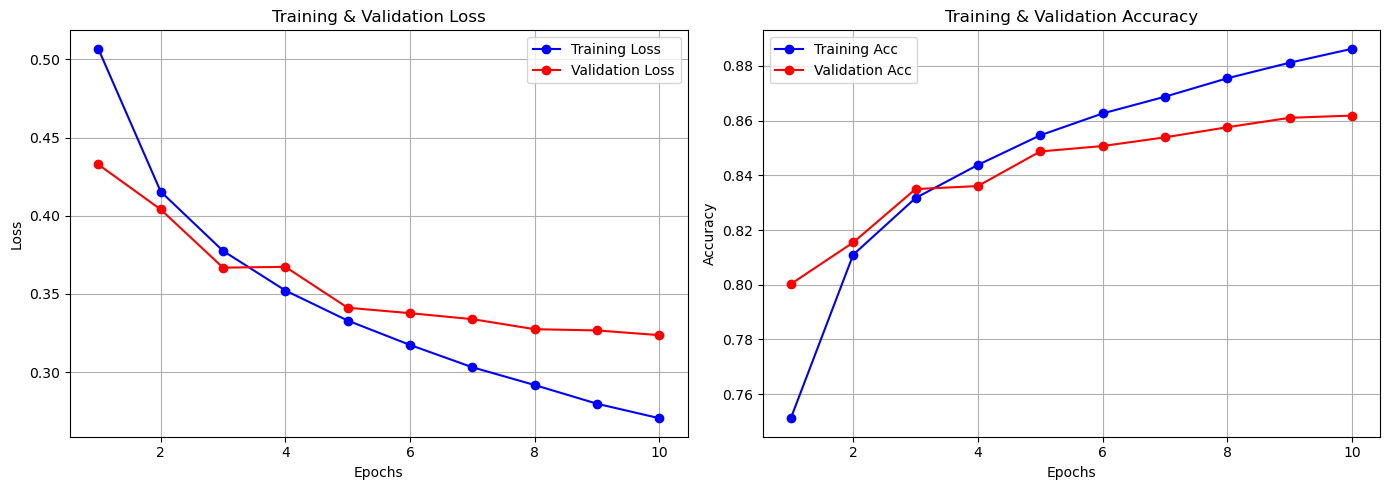

In [72]:
import matplotlib.pyplot as plt

def plot_history(history):
    # 에포크 범위 설정
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Loss 그래프 (손실 함수 감소 추이)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'bo-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'ro-', label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # 2. Accuracy 그래프 (정확도 상승 추이)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'bo-', label='Training Acc')
    plt.plot(epochs, history['val_acc'], 'ro-', label='Validation Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
# 실행
plot_history(history)